In [21]:
!pip install neptune --quiet

# ***About DataSet****
### **train**
- **apple_pie** -1000 фото
- **cheesecake** -1000 фото
- **chicken_curry** -1000 фото
- **french_fries** -1000 фото
- **fried_rice** -1000 фото
- **hamburger** -1000 фото
- **hot_dog** -1000 фото
- **ice_cream** -1000 фото
- **omellete** -1000 фото
- **pizza** -1000 фото
- **sushi** -1000 фото
#### train size: 11000 фото  
### **test**
- **apple_pie** -100 фото
- **cheesecake** -100 фото
- **chicken_curry** -100 фото
- **french_fries** -100 фото
- **fried_rice** -100 фото
- **hamburger** -100 фото
- **hot_dog** -100 фото
- **ice_cream** -100 фото
- **omellete** -100 фото
- **pizza** -100 фото
- **sushi** -100 фото
#### test size: 1100 фото

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.models import (
    efficientnet_b0, efficientnet_b1, efficientnet_b2,
    efficientnet_b3,mobilenet_v2,
    resnet18,
    EfficientNet_B0_Weights, EfficientNet_B1_Weights,
    EfficientNet_B2_Weights, EfficientNet_B3_Weights,
    MobileNet_V2_Weights,ResNet18_Weights
)
from sklearn.metrics import f1_score

from tqdm import tqdm
import neptune
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np


In [23]:
device=torch.device('cuda')

In [24]:
def evaluate(model, dataloader, device, num_classes):
    model.eval()
    accuracy = MulticlassAccuracy(num_classes=num_classes).to(device)
    f1_macro = MulticlassF1Score(num_classes=num_classes, average='macro').to(device)
    f1_weighted = MulticlassF1Score(num_classes=num_classes, average='weighted').to(device)
    
    total_loss = 0.0
    total_samples = 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * images.size(0)
            total_samples += labels.size(0)

            preds = outputs.argmax(dim=1)
            accuracy.update(preds, labels)
            f1_macro.update(preds, labels)
            f1_weighted.update(preds, labels)

    avg_loss = total_loss / total_samples
    acc = accuracy.compute().item()
    f1_mac = f1_macro.compute().item()
    f1_w = f1_weighted.compute().item()

    model.train()
    return avg_loss, acc, f1_mac, f1_w  

In [25]:

def train_model(
    model,
    train_loader,
    test_loader,
    train_dataset,
    num_epochs,
    num_classes,      
    optimizer,
    criterion,
    device=None,
    project_name="kulikovka/CNN-models-test",
    api_token="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiJiNjZjNWE3OS1jMzRlLTQyZjAtYmFiNi04ZGU1ZjY0MDAxNzgifQ=="
):
    model = model.to(device)

    run = neptune.init_run(project=project_name, api_token=api_token)
    run["parameters"] = {
        "epochs": num_epochs,
        "batch_size": train_loader.batch_size,
        "num_classes": num_classes,
        "device": str(device)
    }

    train_losses, train_accs, train_f1s = [], [], []
    test_losses, test_accs, test_f1s = [], [], []

    for epoch in range(1, num_epochs + 1):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0

        f1_train_metric = MulticlassF1Score(num_classes=num_classes, average='weighted').to(device)
        accuracy_train_metric = MulticlassAccuracy(num_classes=num_classes).to(device)

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            accuracy_train_metric.update(preds, labels)
            f1_train_metric.update(preds, labels)

            current_acc = accuracy_train_metric.compute().item()
            pbar.set_postfix({"loss": loss.item(), "acc": f"{100 * current_acc:.1f}%"})

        train_loss = epoch_loss / len(train_dataset)
        train_acc = accuracy_train_metric.compute().item()
        train_f1 = f1_train_metric.compute().item()

        test_loss, test_acc, _, test_f1 = evaluate(model, test_loader, device, num_classes)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        train_f1s.append(train_f1)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        test_f1s.append(test_f1)

        run["train/loss"].append(train_loss)
        run["train/accuracy"].append(train_acc)
        run["train/f1"].append(train_f1)          
        run["test/loss"].append(test_loss)
        run["test/accuracy"].append(test_acc)
        run["test/f1"].append(test_f1)            
        run["epoch"].append(epoch)

        print(f"Epoch {epoch}: "
              f"Train loss={train_loss:.4f}, Acc={train_acc:.4f}, F1={train_f1:.4f} | "
              f"Test loss={test_loss:.4f}, Acc={test_acc:.4f}, F1={test_f1:.4f}")

    run.stop()
    return {
        "train_loss": train_losses,
        "train_acc": train_accs,
        "train_f1": train_f1s,
        "test_loss": test_losses,
        "test_acc": test_accs,
        "test_f1": test_f1s
    }

In [26]:
def plot_confusion_matrix(model, dataloader, class_names):

    model.eval()
    all_labels = []
    all_preds  = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(len(class_names), len(class_names)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Предсказанный класс")
    plt.ylabel("Настоящий класс")
    plt.title("Матрица ошибок")
    plt.show()


In [27]:
data_dir = "/kaggle/input/food11/food11"


# ***EfficientNet-B0***

In [28]:
img_size = 224
batch_size = 16
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(img_size, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize(img_size + 20),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_dataset = datasets.ImageFolder(f"{data_dir}/train", transform=train_transforms)
test_dataset  = datasets.ImageFolder(f"{data_dir}/test",  transform=test_transforms)
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)



In [29]:
num_classes = 11

weights = EfficientNet_B0_Weights.DEFAULT
model_b0 = efficientnet_b0(weights=weights)
model_b0.classifier[1] = nn.Linear(model_b0.classifier[1].in_features, num_classes)
model_b0 = model_b0.to(device)

In [30]:
criterion = nn.CrossEntropyLoss()
optimizer= optim.Adam(model_b0.parameters(), lr=1e-4)
num_epochs=10
device=torch.device('cuda')

In [31]:
train_model(model=model_b0,  train_loader=train_loader,
    test_loader=test_loader,
    train_dataset=train_dataset,
    num_epochs=num_epochs,
    num_classes=num_classes,      
    optimizer=optimizer,
    criterion=criterion,
    device=device,
           )

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/kulikovka/CNN-models-test/e/CNNMOD-6


Epoch 1/10: 100%|██████████| 619/619 [02:05<00:00,  4.94it/s, loss=0.636, acc=66.3%]


Epoch 1: Train loss=1.1216, Acc=0.6631, F1=0.6604 | Test loss=0.4534, Acc=0.8591, F1=0.8589


Epoch 2/10: 100%|██████████| 619/619 [02:05<00:00,  4.93it/s, loss=0.581, acc=82.3%] 


Epoch 2: Train loss=0.5679, Acc=0.8229, F1=0.8226 | Test loss=0.3386, Acc=0.8864, F1=0.8863


...

Epoch 9/10: 100%|██████████| 619/619 [02:04<00:00,  4.99it/s, loss=0.367, acc=93.9%] 


Epoch 9: Train loss=0.1951, Acc=0.9393, F1=0.9393 | Test loss=0.2756, Acc=0.9182, F1=0.9183


Epoch 10/10: 100%|██████████| 619/619 [02:04<00:00,  4.97it/s, loss=0.0143, acc=94.1%] 


Epoch 10: Train loss=0.1857, Acc=0.9414, F1=0.9414 | Test loss=0.2879, Acc=0.9164, F1=0.9163
[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 7 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 7 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/kulikovka/CNN-models-test/e/CNNMOD-6/metadata


{'train_loss': [1.121558916279764,
  0.5679012030904943,
  0.4616100261307726,
  0.37914438684179325,
  0.33326781011591056,
  0.2914837275460513,
  0.25501878996690114,
  0.22779494175179438,
  0.19508102861468238,
  0.18571401827112594],
 'train_acc': [0.6631313562393188,
  0.8229292631149292,
  0.8553534746170044,
  0.880403995513916,
  0.8916161060333252,
  0.9074746966362,
  0.9194949865341187,
  0.9251515865325928,
  0.9392929077148438,
  0.9414141178131104],
 'train_f1': [0.6603802442550659,
  0.8226195573806763,
  0.8552721738815308,
  0.880349338054657,
  0.8915665149688721,
  0.9074207544326782,
  0.9194253087043762,
  0.9251371622085571,
  0.9393011927604675,
  0.9413859844207764],
 'test_loss': [0.4534377878362482,
  0.338561227673834,
  0.29580441772937777,
  0.2867863193154335,
  0.2697201240333644,
  0.26812702666629445,
  0.28201732403175395,
  0.2942323919453404,
  0.27559446240013297,
  0.28793687363917175],
 'test_acc': [0.8590908646583557,
  0.8863636255264282,
  0.

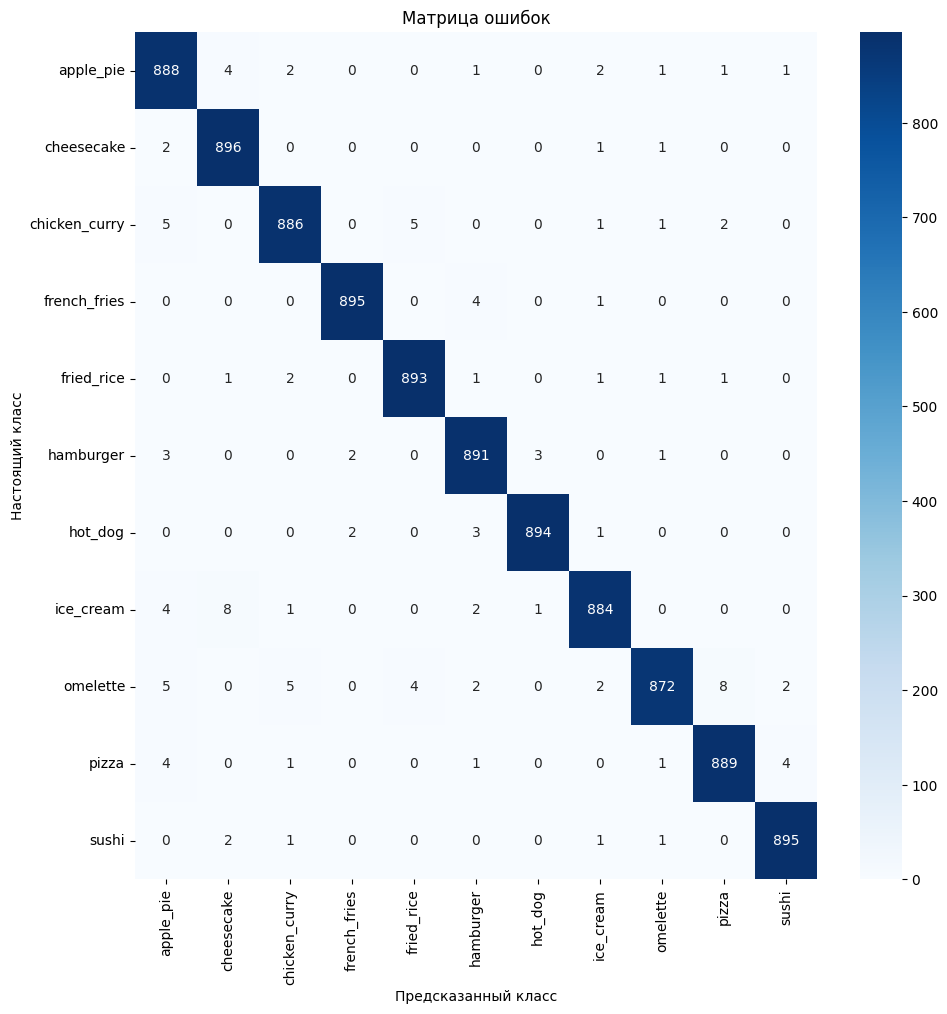

In [32]:
plot_confusion_matrix(model=model_b0, dataloader= train_loader, class_names=rain_dataset.classes )

### ***About EfficientNet-B0***
#### **Метрики**
- **train loss=** ***0.1857*** vs **test loss=** ***0.2879***
- **train f1=** ***0.9414*** vs **test f1=** ***0.9163***
- ***model training time: 21:58**
#### **Confusion Matrix Analytics**
- **chicken_curry**: 5 раз модель предсказала **french_fries**.  
- **french_fries**: 4 раза модель предсказала **fried_rice**.  
- **fried_rice**: 2 раза модель предсказала **chicken_curry** и 1 раз — **hamburger**.  
- **hamburger**: 3 раза модель предсказала **hot_dog**.  
- **hot_dog**: 3 раза модель предсказала **hamburger**.  
- **ice_cream**: 8 раз модель предсказала **cheesecake**.  
- **omelette**: 8 раз модель предсказала **pizza**.  
- **pizza**: 4 раза модель предсказала **omelette**.  

# ***EfficientNet-B1***

In [41]:
weights = EfficientNet_B1_Weights.DEFAULT
model_b1 = efficientnet_b1(weights=weights)
model_b1.classifier[1] = nn.Linear(model_b1.classifier[1].in_features, num_classes)
model_b1 = model_b1.to(device)

In [42]:
img_size = 240
batch_size = 16
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(img_size, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize(img_size + 20),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_dataset = datasets.ImageFolder(f"{data_dir}/train", transform=train_transforms)
test_dataset  = datasets.ImageFolder(f"{data_dir}/test", transform=test_transforms)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [43]:
criterion = nn.CrossEntropyLoss()
optimizer= optim.Adam(model_b1.parameters(), lr=5e-5)
num_epochs=10


In [44]:
train_model(model=model_b1,  train_loader=train_loader,
    test_loader=test_loader,
    train_dataset=train_dataset,
    num_epochs=num_epochs,
    num_classes=num_classes,      
    optimizer=optimizer,
    criterion=criterion,
    device=device,
           )

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/kulikovka/CNN-models-test/e/CNNMOD-10


Epoch 1/10: 100%|██████████| 619/619 [02:38<00:00,  3.92it/s, loss=1.03, acc=62.4%] 


Epoch 1: Train loss=1.3498, Acc=0.6241, F1=0.6239 | Test loss=0.6279, Acc=0.8355, F1=0.8372


Epoch 2/10: 100%|██████████| 619/619 [02:40<00:00,  3.87it/s, loss=0.388, acc=80.8%]


Epoch 2: Train loss=0.6317, Acc=0.8081, F1=0.8082 | Test loss=0.4159, Acc=0.8836, F1=0.8849


...

Epoch 9/10: 100%|██████████| 619/619 [02:38<00:00,  3.91it/s, loss=0.252, acc=91.9%] 


Epoch 9: Train loss=0.2541, Acc=0.9193, F1=0.9193 | Test loss=0.2406, Acc=0.9236, F1=0.9238


Epoch 10/10: 100%|██████████| 619/619 [02:38<00:00,  3.89it/s, loss=0.0664, acc=93.2%] 


Epoch 10: Train loss=0.2217, Acc=0.9318, F1=0.9318 | Test loss=0.2395, Acc=0.9327, F1=0.9329
[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 7 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 7 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/kulikovka/CNN-models-test/e/CNNMOD-10/metadata


{'train_loss': [1.349844595687558,
  0.6316970713572069,
  0.5012730741862095,
  0.42895549390653165,
  0.3895379261838065,
  0.3298359099301425,
  0.29989504997477384,
  0.27002288718717266,
  0.2541142292576607,
  0.22172319765569587],
 'train_acc': [0.6241413950920105,
  0.808080792427063,
  0.8410100340843201,
  0.8688888549804688,
  0.8790909051895142,
  0.8984848856925964,
  0.9066666960716248,
  0.9139394164085388,
  0.9192929267883301,
  0.9318181276321411],
 'train_f1': [0.6238853931427002,
  0.8082256317138672,
  0.8412238955497742,
  0.8689417839050293,
  0.8791570663452148,
  0.8985071778297424,
  0.9067273139953613,
  0.913914680480957,
  0.9193188548088074,
  0.9317878484725952],
 'test_loss': [0.6279381956837394,
  0.41594931732524526,
  0.4001869376139207,
  0.29596346031535753,
  0.3059212686256929,
  0.2936830437725241,
  0.24160743908448654,
  0.35152923770926214,
  0.24058759612115946,
  0.23946533893997018],
 'test_acc': [0.835454523563385,
  0.8836363554000854,
  

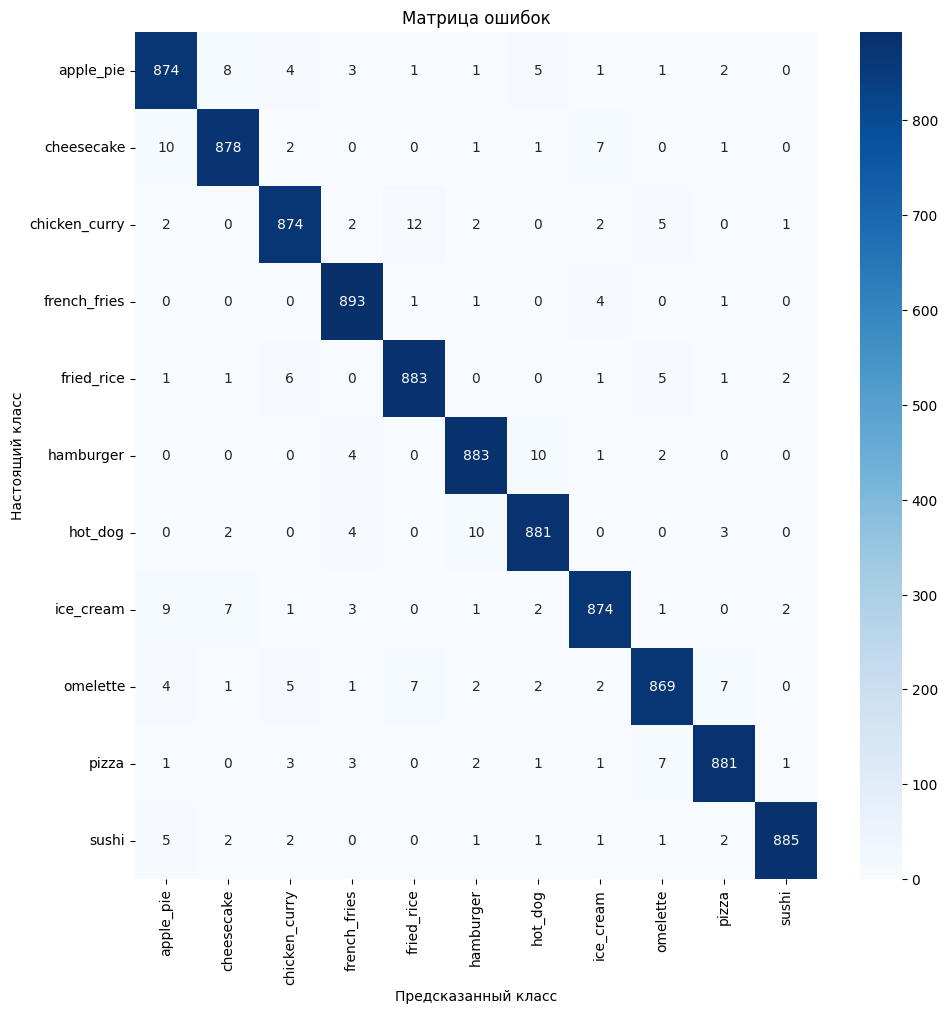

In [45]:
plot_confusion_matrix(model=model_b1, dataloader= train_loader, class_names=train_dataset.classes )

### ***About EfficientNet-B1***
#### **Метрики**
- **train loss=** ***0.2217*** vs **test loss=** ***0.2395***
- **train f1=** ***0.9318*** vs **test f1=** ***0.9329***
- ***model training time: 27:46**
#### **Confusion Matrix Analytics**
- **chicken_curry**: 12 раз модель предсказала **fried_rice**.  
- **fried_rice**: 6 раз модель предсказала **chicken_curry** и 5 раз — **omelette**.  
- **hamburger**: 10 раз модель предсказала **hot_dog**.  
- **hot_dog**: 10 раз модель предсказала **hamburger**.  
- **pizza**: 7 раз модель предсказала **omelette**.  
- **omelette**: 7 раз модель предсказала **pizza**.  

# ***EfficientNet-B2***

In [46]:
weights = EfficientNet_B2_Weights.DEFAULT
model_b2 = efficientnet_b2(weights=weights)
model_b2.classifier[1] = nn.Linear(model_b2.classifier[1].in_features, num_classes)
model_b2 = model_b2.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth
100%|██████████| 35.2M/35.2M [00:00<00:00, 124MB/s] 


In [47]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_b2.parameters(), lr=2e-5)
num_epochs=10


In [48]:
img_size = 260
batch_size = 16
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
test_transforms = transforms.Compose([
    transforms.Resize(img_size + 20),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(f"{data_dir}/train", transform=train_transforms)
test_dataset  = datasets.ImageFolder(f"{data_dir}/test",  transform=test_transforms)
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

In [49]:
train_model(model=model_b2,  train_loader=train_loader,
    test_loader=test_loader,
    train_dataset=train_dataset,
    num_epochs=num_epochs,
    num_classes=num_classes,      
    optimizer=optimizer,
    criterion=criterion,
    device=device,
           )

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/kulikovka/CNN-models-test/e/CNNMOD-11


Epoch 1/10: 100%|██████████| 619/619 [03:13<00:00,  3.20it/s, loss=0.865, acc=49.2%]


Epoch 1: Train loss=1.8090, Acc=0.4923, F1=0.4830 | Test loss=1.0403, Acc=0.7836, F1=0.7786


Epoch 2/10: 100%|██████████| 619/619 [03:13<00:00,  3.20it/s, loss=0.463, acc=76.4%]


Epoch 2: Train loss=0.8586, Acc=0.7643, F1=0.7620 | Test loss=0.5115, Acc=0.8655, F1=0.8665


...

Epoch 9/10: 100%|██████████| 619/619 [03:12<00:00,  3.21it/s, loss=0.297, acc=92.2%] 


Epoch 9: Train loss=0.2546, Acc=0.9223, F1=0.9223 | Test loss=0.2351, Acc=0.9282, F1=0.9284


Epoch 10/10: 100%|██████████| 619/619 [03:14<00:00,  3.19it/s, loss=0.241, acc=93.1%]  


Epoch 10: Train loss=0.2238, Acc=0.9310, F1=0.9310 | Test loss=0.2382, Acc=0.9245, F1=0.9247
[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 7 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 7 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/kulikovka/CNN-models-test/e/CNNMOD-11/metadata


{'train_loss': [1.80903459753653,
  0.8585802007805218,
  0.6008894973812682,
  0.4771368267620453,
  0.4151023831451782,
  0.3671346430916979,
  0.31746322141151234,
  0.28457388849872534,
  0.2546238461136818,
  0.22376132109174224],
 'train_acc': [0.49232321977615356,
  0.7643434405326843,
  0.822929322719574,
  0.8602020144462585,
  0.8736363649368286,
  0.8885858654975891,
  0.9032323360443115,
  0.9150505065917969,
  0.9223232269287109,
  0.9310101270675659],
 'train_f1': [0.48299968242645264,
  0.7619916200637817,
  0.8225255012512207,
  0.8602166175842285,
  0.8736882209777832,
  0.888594925403595,
  0.9032537937164307,
  0.9150083065032959,
  0.9223098754882812,
  0.9309975504875183],
 'test_loss': [1.0402859570763328,
  0.5114808801087466,
  0.38118235444480725,
  0.3288353298198093,
  0.3066704406250607,
  0.2707179298725995,
  0.25338278235359624,
  0.25057822877710517,
  0.2350967301563783,
  0.23817647688768126],
 'test_acc': [0.7836363315582275,
  0.8654544949531555,
  0

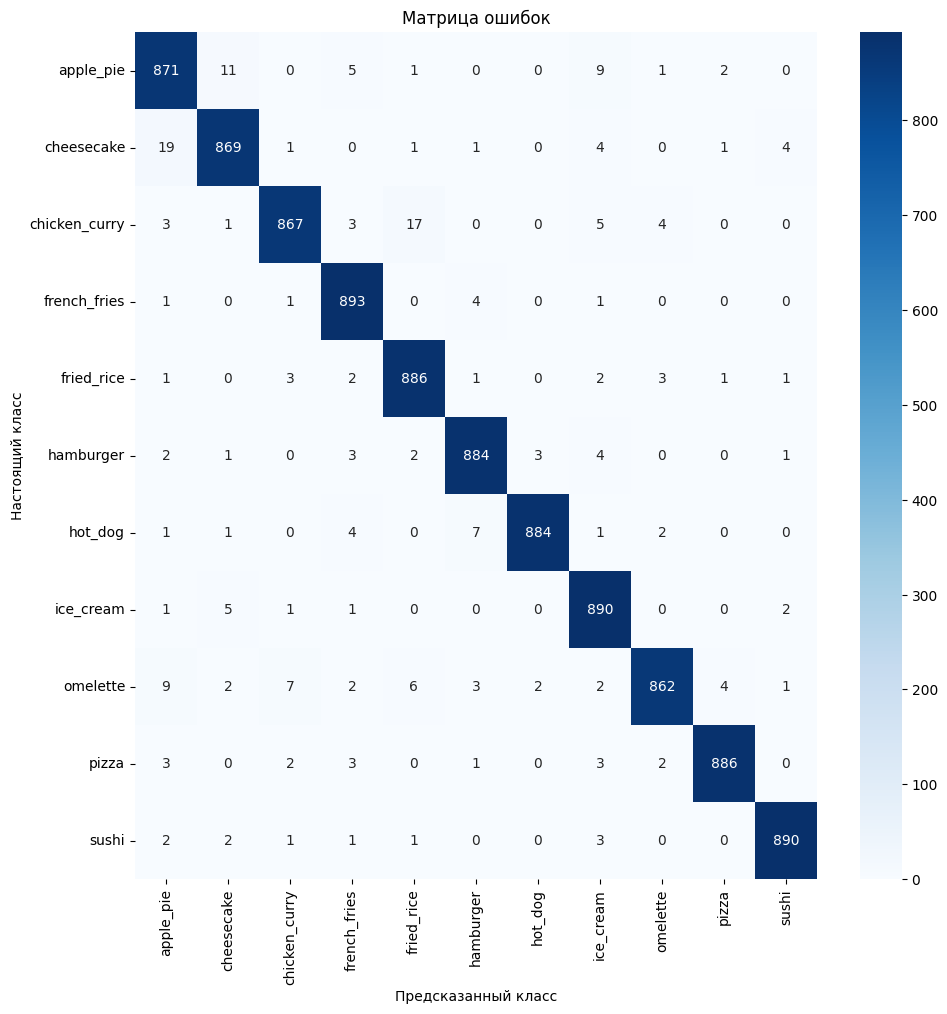

In [50]:
plot_confusion_matrix(model=model_b2, dataloader= train_loader, class_names=train_dataset.classes )

### ***About EfficientNet-B2***
#### **Метрики**
- **train loss=** ***0.2238*** vs **test loss=** ***0.2382***
- **train f1=** ***0.9310*** vs **test f1=** ***0.9247***
- ***model training time: 33:38***

#### **Confusion Matrix Analytics**
- **chicken_curry**: 17 раз модель предсказала **french_fries**.  
- **french_fries**: 4 раза модель предсказала **fried_rice**.  
- **fried_rice**: 3 раза модель предсказала **chicken_curry** и 2 раза — **hamburger**.  
- **hamburger**: 3 раза модель предсказала **hot_dog**.  
- **hot_dog**: 7 раз модель предсказала **hamburger**.  
- **ice_cream**: 5 раз модель предсказала **cheesecake**.  
- **omelette**: 4 раза модель предсказала **pizza**.  
- **pizza**: 3 раза модель предсказала **omelette**.  

Эти пары классов являются наиболее частыми источниками путаницы для модели.

# ***EfficientNet-B3***

In [68]:
weights = EfficientNet_B3_Weights.DEFAULT
model_b3 = efficientnet_b3(weights=weights)
model_b3.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.4, inplace=True),
    torch.nn.Linear(in_features=1536, out_features=num_classes)  
)
model_b3 = model_b3.to(device)

In [69]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_b3.parameters(), lr=1e-4)
num_epochs=15

In [70]:
img_size = 300
batch_size = 16
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(img_size, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize(img_size + 20),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_dataset = datasets.ImageFolder(f"{data_dir}/train", transform=train_transforms)
test_dataset  = datasets.ImageFolder(f"{data_dir}/test",  transform=test_transforms)
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)


In [71]:
train_model(model=model_b3,  train_loader=train_loader,
    test_loader=test_loader,
    train_dataset=train_dataset,
    num_epochs=num_epochs,
    num_classes=num_classes,      
    optimizer=optimizer,
    criterion=criterion,
    device=device,
           )

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/kulikovka/CNN-models-test/e/CNNMOD-16


Epoch 1/15: 100%|██████████| 619/619 [04:43<00:00,  2.19it/s, loss=0.916, acc=69.4%]


Epoch 1: Train loss=1.0340, Acc=0.6938, F1=0.6941 | Test loss=0.3330, Acc=0.9064, F1=0.9067


Epoch 2/15: 100%|██████████| 619/619 [04:44<00:00,  2.18it/s, loss=0.456, acc=86.8%] 


Epoch 2: Train loss=0.4282, Acc=0.8679, F1=0.8677 | Test loss=0.2560, Acc=0.9191, F1=0.9190


...

Epoch 14/15: 100%|██████████| 619/619 [04:43<00:00,  2.19it/s, loss=0.0129, acc=97.9%]  


Epoch 14: Train loss=0.0662, Acc=0.9787, F1=0.9787 | Test loss=0.2963, Acc=0.9345, F1=0.9347


Epoch 15/15: 100%|██████████| 619/619 [04:42<00:00,  2.19it/s, loss=0.00897, acc=98.1%] 


Epoch 15: Train loss=0.0590, Acc=0.9808, F1=0.9808 | Test loss=0.2753, Acc=0.9418, F1=0.9419
[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 7 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 7 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/kulikovka/CNN-models-test/e/CNNMOD-16/metadata


{'train_loss': [1.0340236484643184,
  0.4281685517352037,
  0.3219949021258137,
  0.2576141584958091,
  0.2033517054344217,
  0.17168008276308425,
  0.14426395823106622,
  0.1229031415750282,
  0.11098000852758008,
  0.09513999228092908,
  0.08142626563726801,
  0.07624931267763704,
  0.077812993955996,
  0.0662416168387904,
  0.05902779343716725],
 'train_acc': [0.6938384175300598,
  0.867878794670105,
  0.8987878561019897,
  0.9197980165481567,
  0.9363636374473572,
  0.9481818675994873,
  0.9542424082756042,
  0.9597980380058289,
  0.9659595489501953,
  0.9706060886383057,
  0.9748485088348389,
  0.977070689201355,
  0.9744445085525513,
  0.9786868691444397,
  0.9808081388473511],
 'train_f1': [0.6940649151802063,
  0.8677225708961487,
  0.8987533450126648,
  0.9197862148284912,
  0.9363458752632141,
  0.9481550455093384,
  0.9542325735092163,
  0.9597569704055786,
  0.9659456014633179,
  0.970593273639679,
  0.9748556613922119,
  0.9770746231079102,
  0.9744411110877991,
  0.978678

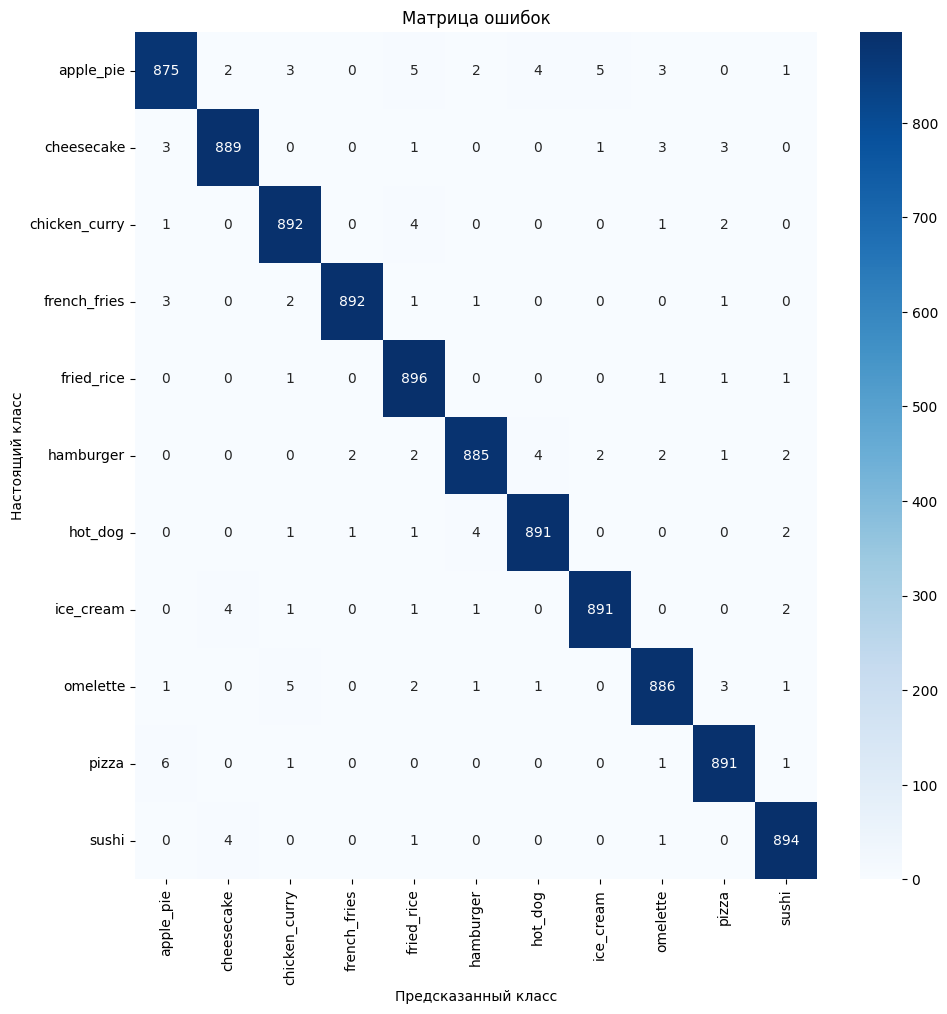

In [77]:
plot_confusion_matrix(model=model_b3, dataloader= train_loader, class_names=train_dataset.classes )

# ***MobileNetV2***

In [90]:
weights = MobileNet_V2_Weights.DEFAULT  
model_mobilenetv2 = mobilenet_v2(weights=weights)
model_mobilenetv2.classifier[1] = nn.Linear(model_mobilenetv2.classifier[1].in_features,num_classes)
model_mobilenetv2=model_mobilenetv2.to(device)

In [91]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_mobilenetv2.parameters(), lr=1e-4)
num_epochs=10

In [92]:
img_size = 224
batch_size =32 
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(img_size, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize(img_size + 20),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_dataset = datasets.ImageFolder(f"{data_dir}/train", transform=train_transforms)
test_dataset  = datasets.ImageFolder(f"{data_dir}/test",  transform=test_transforms)
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)


In [93]:
train_model(model=model_mobilenetv2,  
    train_loader=train_loader,
    test_loader=test_loader,
    train_dataset=train_dataset,
    num_epochs=num_epochs,
    num_classes=num_classes,      
    optimizer=optimizer,
    criterion=criterion,
    device=device,
)

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/kulikovka/CNN-models-test/e/CNNMOD-21


Epoch 1/10: 100%|██████████| 310/310 [01:49<00:00,  2.83it/s, loss=0.909, acc=61.6%]


Epoch 1: Train loss=1.3397, Acc=0.6160, F1=0.6140 | Test loss=0.6268, Acc=0.8200, F1=0.8211


Epoch 2/10: 100%|██████████| 310/310 [01:48<00:00,  2.85it/s, loss=0.61, acc=79.8%] 


Epoch 2: Train loss=0.6475, Acc=0.7985, F1=0.7983 | Test loss=0.4649, Acc=0.8527, F1=0.8533


...

Epoch 9/10: 100%|██████████| 310/310 [01:49<00:00,  2.84it/s, loss=0.182, acc=92.8%] 


Epoch 9: Train loss=0.2347, Acc=0.9282, F1=0.9282 | Test loss=0.3347, Acc=0.8991, F1=0.8992


Epoch 10/10: 100%|██████████| 310/310 [01:49<00:00,  2.83it/s, loss=0.215, acc=93.3%] 


Epoch 10: Train loss=0.2140, Acc=0.9325, F1=0.9325 | Test loss=0.3324, Acc=0.8945, F1=0.8949
[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 7 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 7 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/kulikovka/CNN-models-test/e/CNNMOD-21/metadata


{'train_loss': [1.3397380896529767,
  0.6475468417129131,
  0.4925034088558621,
  0.4234287538913765,
  0.3593052840473676,
  0.3215438838318141,
  0.2782834217163047,
  0.2456691195146002,
  0.23470742802427272,
  0.21400821273977105],
 'train_acc': [0.6159595847129822,
  0.7984848022460938,
  0.845252513885498,
  0.8660606145858765,
  0.8852525353431702,
  0.8955555558204651,
  0.9112120866775513,
  0.9220201969146729,
  0.9281818270683289,
  0.9325252771377563],
 'train_f1': [0.614034116268158,
  0.7982945442199707,
  0.8451914191246033,
  0.8659672141075134,
  0.8852481245994568,
  0.8954876065254211,
  0.9111242294311523,
  0.9219789505004883,
  0.9281563758850098,
  0.932517409324646],
 'test_loss': [0.6267599600011652,
  0.4648679746281017,
  0.395265456979925,
  0.3812585110014135,
  0.35352375480261716,
  0.3294196967645125,
  0.33331866519017656,
  0.339498036774722,
  0.33468889913775707,
  0.3323749816146764],
 'test_acc': [0.8199999928474426,
  0.8527272939682007,
  0.8836

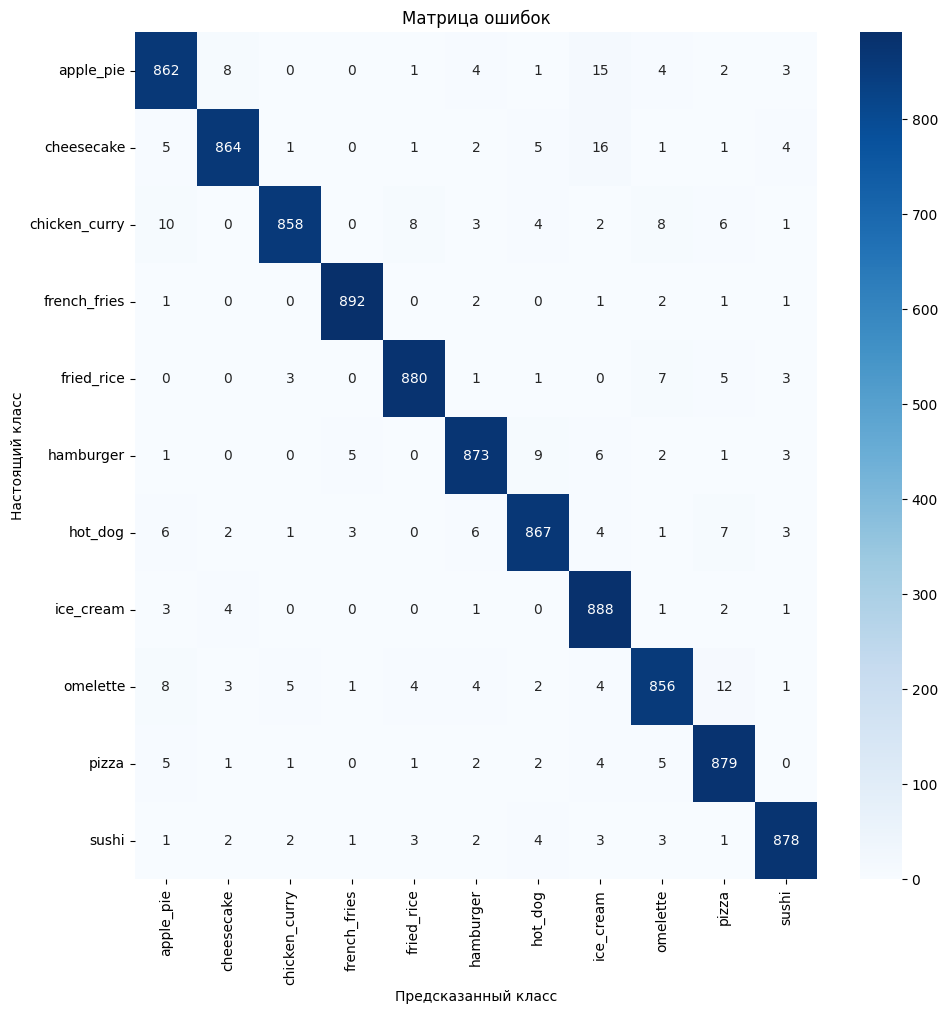

[neptune] [info   ] Shutting down background jobs, please wait a moment...


In [94]:
plot_confusion_matrix(model=model_mobilenetv2, dataloader= train_loader, class_names=train_dataset.classes )

# ***ResNet18***

In [86]:
weights = ResNet18_Weights.DEFAULT
model_resnet18 = resnet18(weights=weights)
model_resnet18.fc = nn.Linear(model_resnet18.fc.in_features, num_classes)
model_resnet18=model_resnet18.to(device)

In [87]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_resnet18.parameters(), lr=1e-4)
num_epochs=10

In [88]:
img_size = 224
batch_size = 32 
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(img_size, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize(img_size + 20),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_dataset = datasets.ImageFolder(f"{data_dir}/train", transform=train_transforms)
test_dataset  = datasets.ImageFolder(f"{data_dir}/test",  transform=test_transforms)
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)


In [89]:
train_model(model=model_resnet18,  
    train_loader=train_loader,
    test_loader=test_loader,
    train_dataset=train_dataset,
    num_epochs=num_epochs,
    num_classes=num_classes,      
    optimizer=optimizer,
    criterion=criterion,
    device=device,
)

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/kulikovka/CNN-models-test/e/CNNMOD-20


Epoch 1/10: 100%|██████████| 310/310 [01:42<00:00,  3.03it/s, loss=1.03, acc=70.4%] 


Epoch 1: Train loss=0.9439, Acc=0.7036, F1=0.7025 | Test loss=0.5847, Acc=0.8200, F1=0.8211


Epoch 2/10: 100%|██████████| 310/310 [01:41<00:00,  3.06it/s, loss=1.05, acc=81.5%] 


Epoch 2: Train loss=0.5772, Acc=0.8155, F1=0.8155 | Test loss=0.4790, Acc=0.8527, F1=0.8528


...

Epoch 9/10: 100%|██████████| 310/310 [01:42<00:00,  3.04it/s, loss=0.551, acc=92.6%] 


Epoch 9: Train loss=0.2285, Acc=0.9260, F1=0.9259 | Test loss=0.4368, Acc=0.8745, F1=0.8753


Epoch 10/10: 100%|██████████| 310/310 [01:41<00:00,  3.05it/s, loss=0.34, acc=92.7%]  


Epoch 10: Train loss=0.2204, Acc=0.9266, F1=0.9265 | Test loss=0.4200, Acc=0.8836, F1=0.8841
[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 7 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 7 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/kulikovka/CNN-models-test/e/CNNMOD-20/metadata


{'train_loss': [0.9438597856386743,
  0.5771611347102156,
  0.4650864196786977,
  0.3929720853795909,
  0.352576045664874,
  0.30459483290862555,
  0.28118355840143533,
  0.2562346374205869,
  0.22845814536316225,
  0.22040766645561566],
 'train_acc': [0.7036364078521729,
  0.8154545426368713,
  0.8510100841522217,
  0.8746464252471924,
  0.8891918659210205,
  0.9035353660583496,
  0.9088888168334961,
  0.9169696569442749,
  0.925959587097168,
  0.9265656471252441],
 'train_f1': [0.7025325298309326,
  0.815543532371521,
  0.8509443402290344,
  0.8745777606964111,
  0.8891192674636841,
  0.9034779071807861,
  0.9088153839111328,
  0.9169313311576843,
  0.9259344339370728,
  0.9265296459197998],
 'test_loss': [0.5846810100295327,
  0.47895147746259514,
  0.44035020405595954,
  0.47669939268719064,
  0.4282344356992028,
  0.396453823487867,
  0.43132802792570807,
  0.44230959767645056,
  0.43675928847356277,
  0.42002711621197786],
 'test_acc': [0.8199999928474426,
  0.8527272343635559,
 

In [ ]:
plot_confusion_matrix(model=model_resnet18, dataloader= train_loader, class_names=train_dataset.classes )